# EDA of Enriched Ad Copy Dataset
Using huggingface ad copies, enriched via LLM, perform quick EDA again to verify results.

In [1]:
import pandas as pd
ad_copy_df = pd.read_csv("../data/enriched_ads_with_metrics.csv")
ad_copy_df.head(5)

,ad_id,campaign_id,headline_text,body_text,call_to_action,platform,placement,ad_format,category,impressions,clicks,conversions,spend,ctr,cvr,cpc,cpa,high_performer
0,enriched_ad_0001,campaign_007,AMAZING GRACE FELLOWSHIP,"1061 Eastland Drive North, Twin Falls Idaho. S...",NaN,NaN,NaN,image,ecommerce,48060,849,80,826.61,0.017665,0.094229,0.973628,10.332625,0
1,enriched_ad_0002,campaign_013,Zolucky,- Up to -\n50%,Shop Now,NaN,NaN,image,ecommerce,46854,816,78,790.56,0.017416,0.095588,0.968824,10.135385,0
2,enriched_ad_0003,campaign_042,Academy Presents Hang With Terrrell Owens And ...,Join us for an exciting event featuring COWBOY...,Get Your Free Tickets,NaN,NaN,image,entertainment,35111,834,105,252.85,0.023753,0.125899,0.303177,2.408095,1
3,enriched_ad_0004,campaign_022,Time to OREGON's MT. HOOD TERRITORY SPRUCE THI...,NaN,Learn More,NaN,NaN,image,ecommerce,84574,1188,72,981.45,0.014047,0.060606,0.826136,13.631250,0
4,enriched_ad_0005,campaign_037,FARMERS INSURANCE,Jeremy Belcourt | CONSTRUCTION COSTS | Ensure ...,Review Your Coverage,NaN,NaN,image,ecommerce,37296,540,55,394.54,0.014479,0.101852,0.730630,7.173455,0


In [2]:
print('Shape of the dataframe:', ad_copy_df.shape)

Shape of the dataframe: (7000, 18)


In [3]:
ad_copy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ad_id           7000 non-null   object 
 1   campaign_id     7000 non-null   object 
 2   headline_text   7000 non-null   object 
 3   body_text       5324 non-null   object 
 4   call_to_action  3519 non-null   object 
 5   platform        637 non-null    object 
 6   placement       0 non-null      float64
 7   ad_format       7000 non-null   object 
 8   category        6724 non-null   object 
 9   impressions     7000 non-null   int64  
 10  clicks          7000 non-null   int64  
 11  conversions     7000 non-null   int64  
 12  spend           7000 non-null   float64
 13  ctr             7000 non-null   float64
 14  cvr             7000 non-null   float64
 15  cpc             7000 non-null   float64
 16  cpa             7000 non-null   float64
 17  high_performer  7000 non-null   i

Note: Placement column is all null, can drop later.

In [4]:
ad_copy_df.describe()

,placement,impressions,clicks,conversions,spend,ctr,cvr,cpc,cpa,high_performer
count,0.0,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,NaN,59825.630857,1035.978143,97.316857,770.832111,0.017330,0.088355,0.839632,14.402534,0.250000
std,NaN,23180.980868,503.212849,77.319969,432.149374,0.004712,0.037449,0.494649,20.407329,0.433044
min,NaN,20013.000000,148.000000,3.000000,102.950000,0.007006,0.011086,0.143629,0.774388,0.000000
25%,NaN,39345.000000,643.000000,46.000000,436.185000,0.013850,0.062040,0.504931,4.827480,0.000000
50%,NaN,59505.500000,961.500000,75.500000,686.615000,0.016863,0.082141,0.775085,10.165259,0.000000
75%,NaN,80192.250000,1343.000000,122.000000,1031.580000,0.019950,0.101801,1.043012,15.198112,0.250000
max,NaN,99986.000000,3465.000000,626.000000,3041.230000,0.036379,0.194682,4.631301,253.773636,1.000000


Campaign Id was generated via LLM, check the stats.

In [5]:
ad_copy_df['campaign_id'].value_counts().head(10)

campaign_id
campaign_017    164
campaign_044    157
campaign_030    156
campaign_027    156
campaign_025    155
campaign_008    154
campaign_034    154
campaign_040    152
campaign_041    151
campaign_033    150
Name: count, dtype: int64

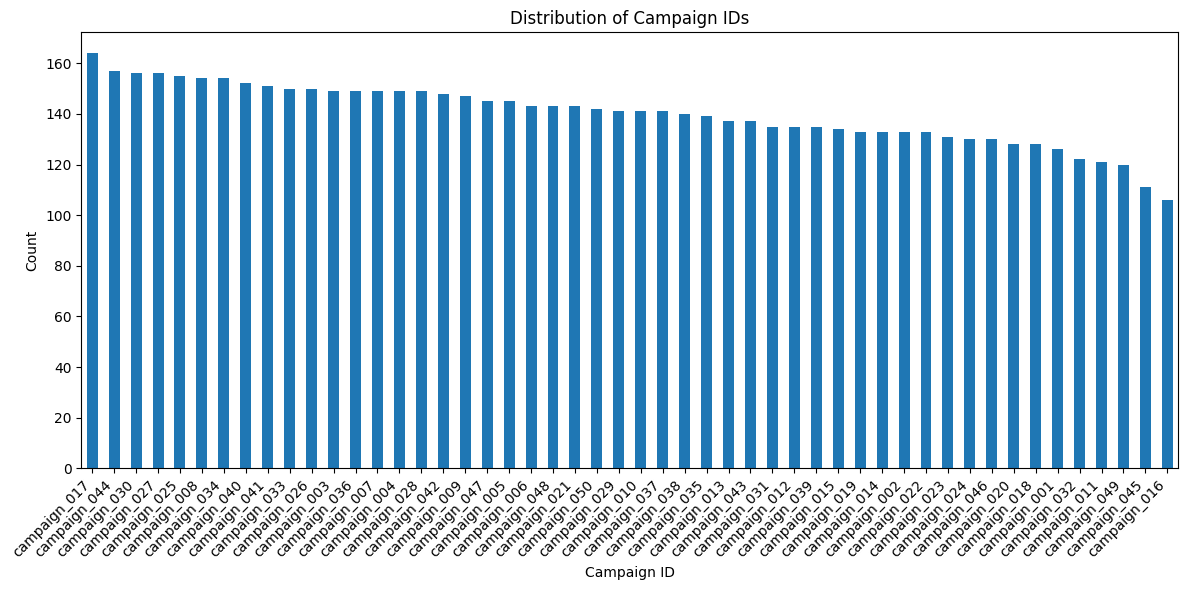

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ad_copy_df['campaign_id'].value_counts().plot(kind='bar')
plt.title('Distribution of Campaign IDs')
plt.xlabel('Campaign ID')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Relatively even, moving on for now...

In [8]:
print('Value counts for categorical columns:')
categorical_cols = ['platform', 'ad_format', 'category', 'high_performer']
for col in categorical_cols:
    print(f'\n{col}:')
    print(ad_copy_df[col].value_counts())

Value counts for categorical columns:

platform:
platform
facebook                    584
instagram                    11
youtube                       5
topcontent-entertainment      3
google play                   2
steam                         2
peacock                       2
all-in-1 digitalcontent       2
website                       2
apple_news                    2
paramount+                    2
twitter                       2
amazon                        2
chaturbate                    1
apple_podcasts                1
alldigimedia.com              1
mount+                        1
online                        1
mount                         1
smart speakers                1
hulu                          1
app_store                     1
app store                     1
disney+                       1
fiverr                        1
browser                       1
siriusxm                      1
instacart                     1
streaming                     1
Name: count, d

Consider filtering to just 'Facebook, Instagram, Youtube' for platforms.

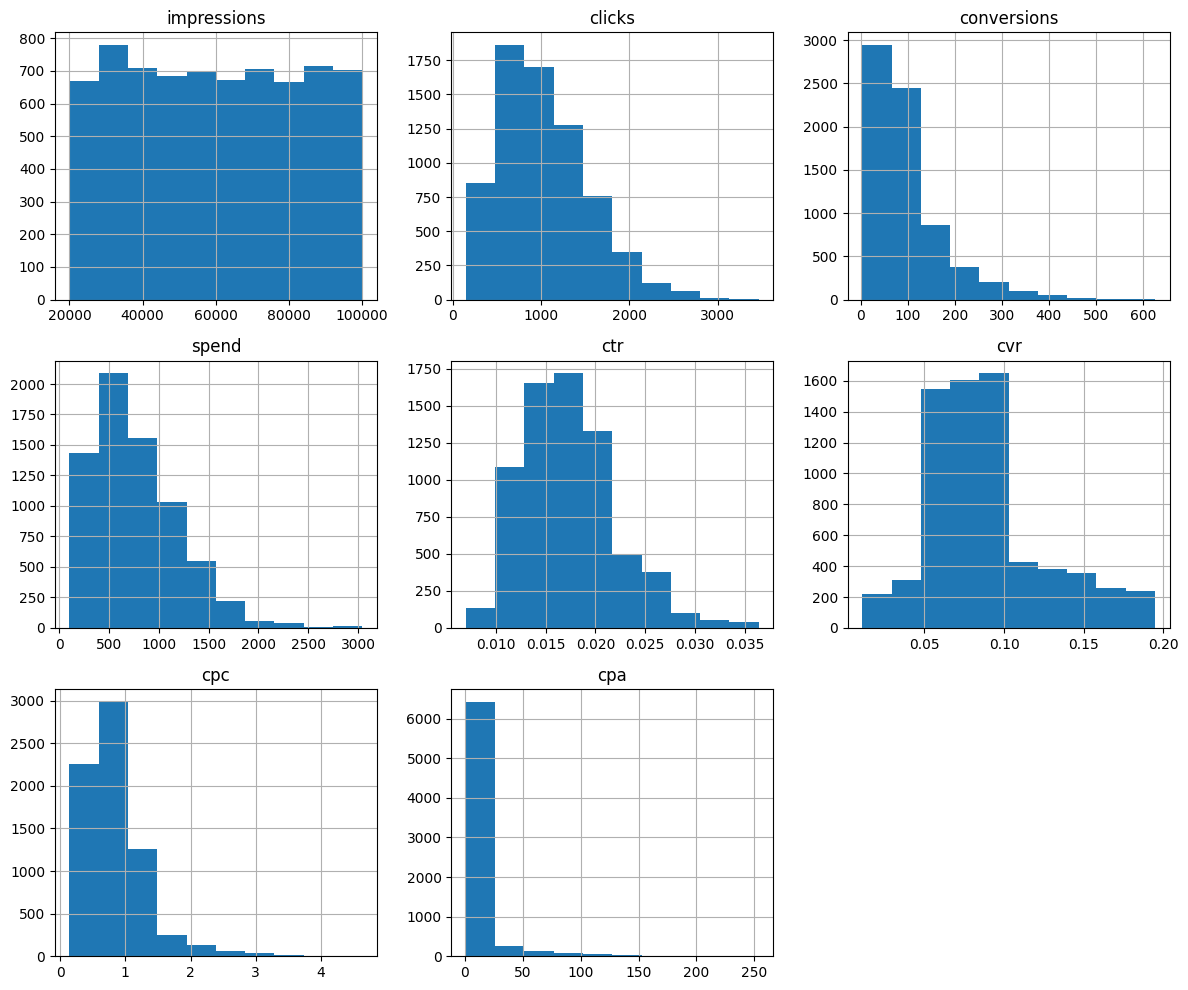

In [3]:
import matplotlib.pyplot as plt
numerical_cols = ['impressions', 'clicks', 'conversions', 'spend', 'ctr', 'cvr', 'cpc', 'cpa']
ad_copy_df[numerical_cols].hist(figsize=(12, 10), bins=10)
plt.tight_layout()
plt.show()

In [10]:
print('Correlation matrix for numerical columns:')
ad_copy_df[numerical_cols].corr()

Correlation matrix for numerical columns:


,impressions,clicks,conversions,spend,ctr,cvr,cpc,cpa
impressions,1.000000,0.796868,0.495944,0.695617,-0.007082,0.011526,0.008733,0.000835
clicks,0.796868,1.000000,0.818365,0.331777,0.557802,0.306938,-0.397818,-0.262445
conversions,0.495944,0.818365,1.000000,-0.068447,0.646118,0.732959,-0.548224,-0.399816
spend,0.695617,0.331777,-0.068447,1.000000,-0.348526,-0.454887,0.598075,0.457240
ctr,-0.007082,0.557802,0.646118,-0.348526,1.000000,0.523725,-0.720288,-0.469994
cvr,0.011526,0.306938,0.732959,-0.454887,0.523725,1.000000,-0.638689,-0.566521
cpc,0.008733,-0.397818,-0.548224,0.598075,-0.720288,-0.638689,1.000000,0.809184
cpa,0.000835,-0.262445,-0.399816,0.457240,-0.469994,-0.566521,0.809184,1.000000


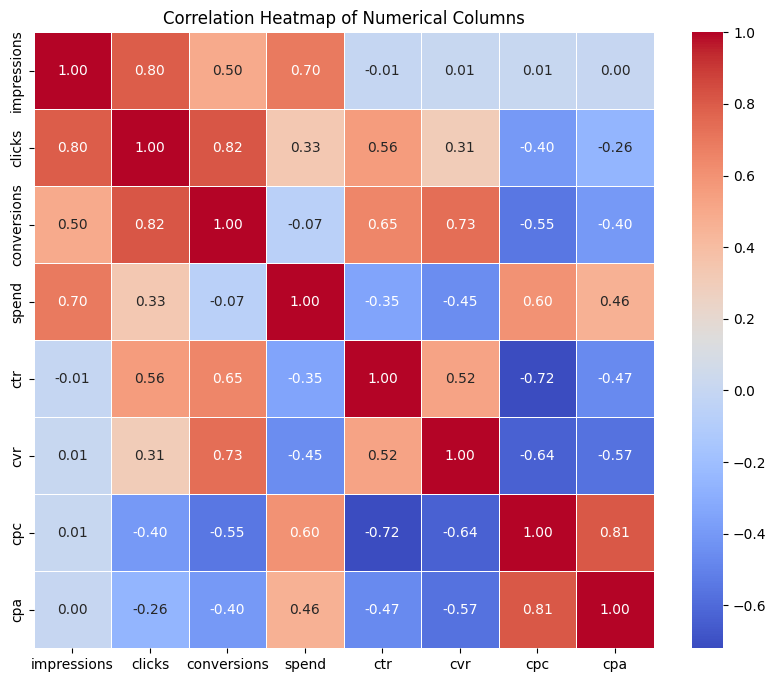

In [4]:
import seaborn as sns
corr_matrix = ad_copy_df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()